In [1]:
# Instalar PySpark en Google Colab
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.2-py2.py3-none-any.whl size=317812365 sha256=7f493c07556ec07145b002f7d8dd0f1ac9ec19af2459871c3c343fa53a21832c
  Stored in directory: /root/.cache/pip/wheels/34/34/bd/03944534c44b677cd5859f248090daa9fb27b3c8f8e5f49574
Successfully built pyspark


In [10]:
# librerias
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, LinearSVC, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Crear una SparkSession
spark = SparkSession.builder.appName("heart").getOrCreate()

# Cargar el archivo CSV en un DataFrame de PySpark
file_path = "heart.csv"
spark_df = spark.read.csv(file_path, header=True, inferSchema=True)

# Mostrar las primeras filas del DataFrame
spark_df.show()


+---+---+---+------+----+---+-------+--------+----+-------+---+---+-----+------+
|age|sex| cp|trtbps|chol|fbs|restecg|thalachh|exng|oldpeak|slp|caa|thall|output|
+---+---+---+------+----+---+-------+--------+----+-------+---+---+-----+------+
| 63|  1|  3|   145| 233|  1|      0|     150|   0|    2.3|  0|  0|    1|     1|
| 37|  1|  2|   130| 250|  0|      1|     187|   0|    3.5|  0|  0|    2|     1|
| 41|  0|  1|   130| 204|  0|      0|     172|   0|    1.4|  2|  0|    2|     1|
| 56|  1|  1|   120| 236|  0|      1|     178|   0|    0.8|  2|  0|    2|     1|
| 57|  0|  0|   120| 354|  0|      1|     163|   1|    0.6|  2|  0|    2|     1|
| 57|  1|  0|   140| 192|  0|      1|     148|   0|    0.4|  1|  0|    1|     1|
| 56|  0|  1|   140| 294|  0|      0|     153|   0|    1.3|  1|  0|    2|     1|
| 44|  1|  1|   120| 263|  0|      1|     173|   0|    0.0|  2|  0|    3|     1|
| 52|  1|  2|   172| 199|  1|      1|     162|   0|    0.5|  2|  0|    3|     1|
| 57|  1|  2|   150| 168|  0

In [7]:
# Definir las características y la etiqueta
feature_columns = ["age", "sex", "cp", "trtbps", "chol", "fbs", "restecg", "thalachh", "exng", "oldpeak", "slp", "caa", "thall"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Transformar los datos
data = assembler.transform(spark_df)
data = data.select(["features", "output"])

In [9]:
# Dividir los datos en entrenamiento y prueba
train_data, test_data = data.randomSplit([0.7, 0.3], seed=1234)

# Definir los modelos
models = [
    ("Logistic Regression", LogisticRegression(featuresCol='features', labelCol='output')),
    ("Decision Tree", DecisionTreeClassifier(featuresCol='features', labelCol='output')),
    ("Random Forest", RandomForestClassifier(featuresCol='features', labelCol='output')),
    ("GBT", GBTClassifier(featuresCol='features', labelCol='output')),
    ("SVM", LinearSVC(featuresCol='features', labelCol='output')),
    ("Naive Bayes", NaiveBayes(featuresCol='features', labelCol='output'))
]

# Evaluador
evaluator = MulticlassClassificationEvaluator(labelCol="output", predictionCol="prediction", metricName="accuracy")

best_acc = 0.0
best_model_name = ""

# Entrenar y evaluar los modelos
for name, model in models:
    model_fit = model.fit(train_data)
    predictions = model_fit.transform(test_data)

    accuracy = evaluator.evaluate(predictions)
    print(f"Accuracy for {name} = {accuracy}")

    if accuracy > best_acc:
        best_acc = accuracy
        best_model_name = name

print(f"\nThe best model is: {best_model_name} with Accuracy = {best_acc:.2f}")

Accuracy for Logistic Regression = 0.797979797979798
Accuracy for Decision Tree = 0.7777777777777778
Accuracy for Random Forest = 0.8080808080808081
Accuracy for GBT = 0.7676767676767676
Accuracy for SVM = 0.7878787878787878
Accuracy for Naive Bayes = 0.7575757575757576

The best model is: Random Forest with Accuracy = 0.81


+---+---+---+------+----+---+-------+--------+----+-------+---+---+-----+------+
|age|sex| cp|trtbps|chol|fbs|restecg|thalachh|exng|oldpeak|slp|caa|thall|output|
+---+---+---+------+----+---+-------+--------+----+-------+---+---+-----+------+
| 63|  1|  3|   145| 233|  1|      0|     150|   0|    2.3|  0|  0|    1|     1|
| 37|  1|  2|   130| 250|  0|      1|     187|   0|    3.5|  0|  0|    2|     1|
| 41|  0|  1|   130| 204|  0|      0|     172|   0|    1.4|  2|  0|    2|     1|
| 56|  1|  1|   120| 236|  0|      1|     178|   0|    0.8|  2|  0|    2|     1|
| 57|  0|  0|   120| 354|  0|      1|     163|   1|    0.6|  2|  0|    2|     1|
| 57|  1|  0|   140| 192|  0|      1|     148|   0|    0.4|  1|  0|    1|     1|
| 56|  0|  1|   140| 294|  0|      0|     153|   0|    1.3|  1|  0|    2|     1|
| 44|  1|  1|   120| 263|  0|      1|     173|   0|    0.0|  2|  0|    3|     1|
| 52|  1|  2|   172| 199|  1|      1|     162|   0|    0.5|  2|  0|    3|     1|
| 57|  1|  2|   150| 168|  0

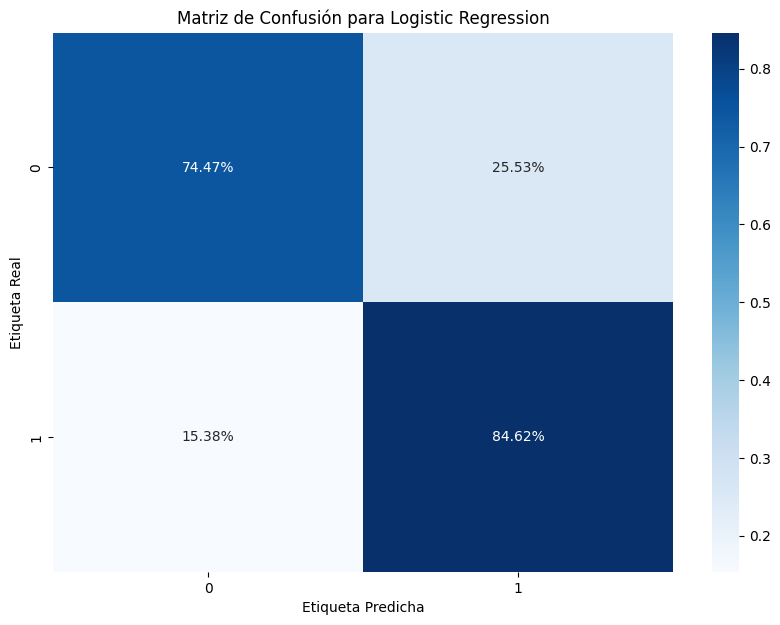

Reporte de Clasificación para Logistic Regression:
              precision    recall  f1-score   support

           0       0.81      0.74      0.78        47
           1       0.79      0.85      0.81        52

    accuracy                           0.80        99
   macro avg       0.80      0.80      0.80        99
weighted avg       0.80      0.80      0.80        99

F1-Score para Logistic Regression: 0.7972315750093528



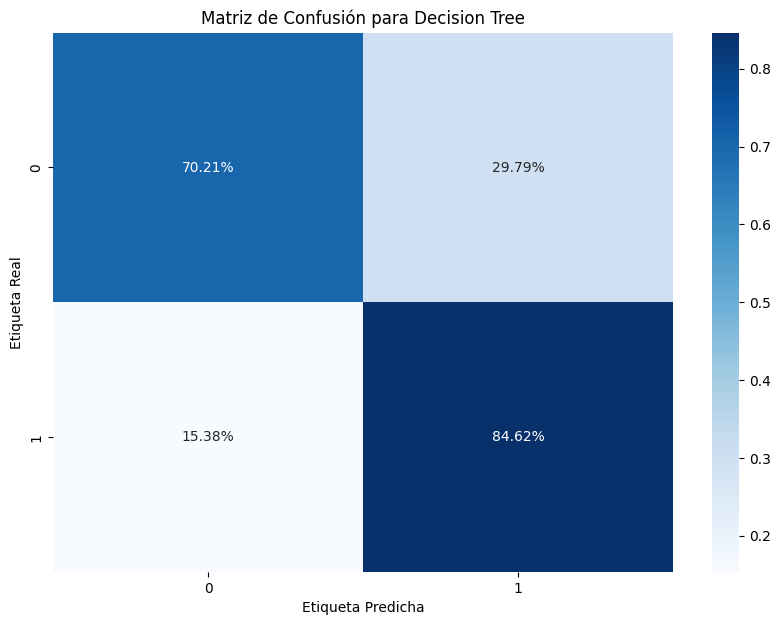

Reporte de Clasificación para Decision Tree:
              precision    recall  f1-score   support

           0       0.80      0.70      0.75        47
           1       0.76      0.85      0.80        52

    accuracy                           0.78        99
   macro avg       0.78      0.77      0.78        99
weighted avg       0.78      0.78      0.78        99

F1-Score para Decision Tree: 0.7762626262626264



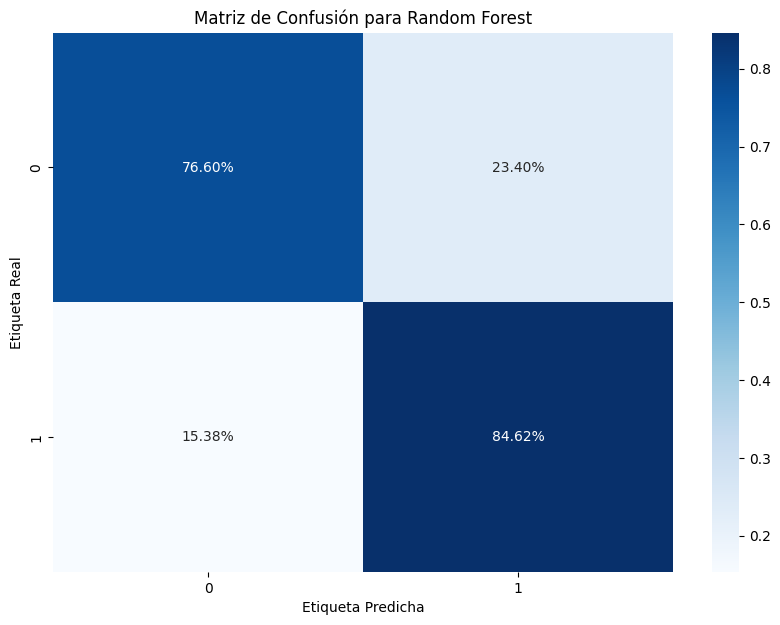

Reporte de Clasificación para Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        47
           1       0.80      0.85      0.82        52

    accuracy                           0.81        99
   macro avg       0.81      0.81      0.81        99
weighted avg       0.81      0.81      0.81        99

F1-Score para Random Forest: 0.807607760878789



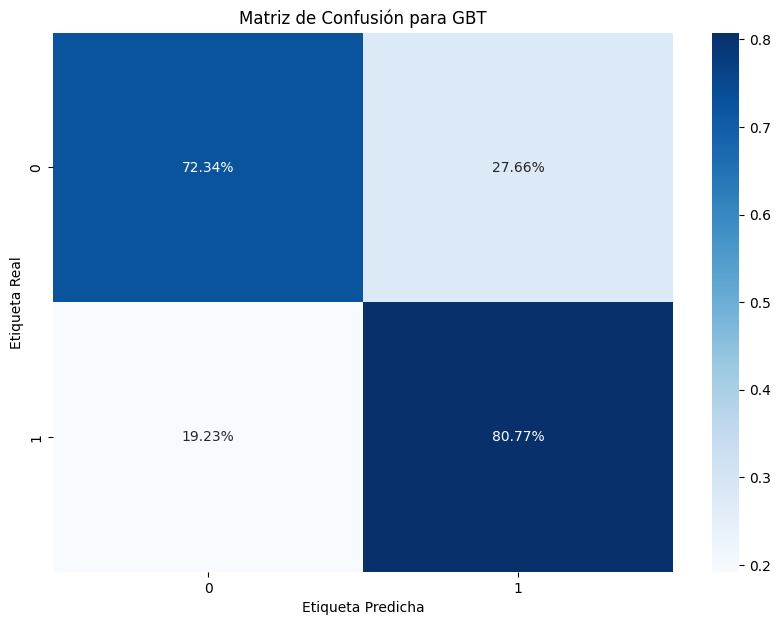

Reporte de Clasificación para GBT:
              precision    recall  f1-score   support

           0       0.77      0.72      0.75        47
           1       0.76      0.81      0.79        52

    accuracy                           0.77        99
   macro avg       0.77      0.77      0.77        99
weighted avg       0.77      0.77      0.77        99

F1-Score para GBT: 0.7671041315901129



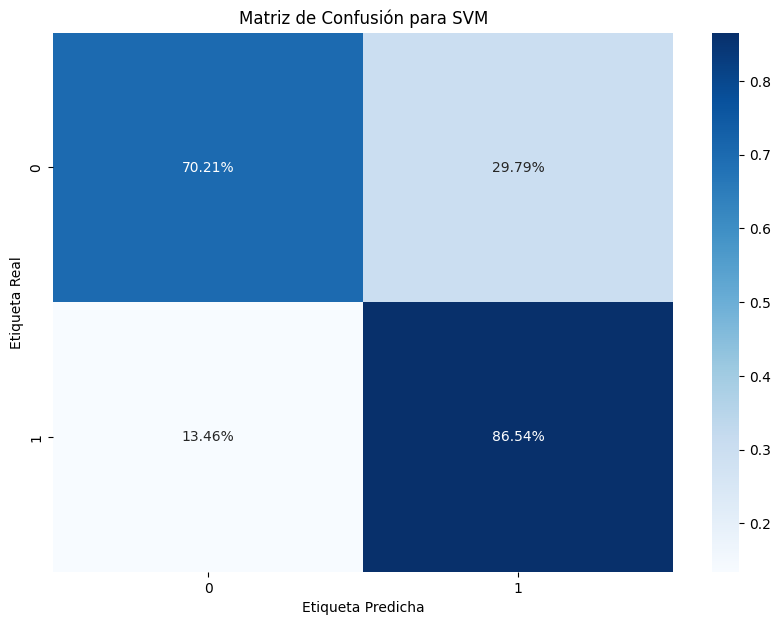

Reporte de Clasificación para SVM:
              precision    recall  f1-score   support

           0       0.82      0.70      0.76        47
           1       0.76      0.87      0.81        52

    accuracy                           0.79        99
   macro avg       0.79      0.78      0.78        99
weighted avg       0.79      0.79      0.79        99

F1-Score para SVM: 0.7860336825854066



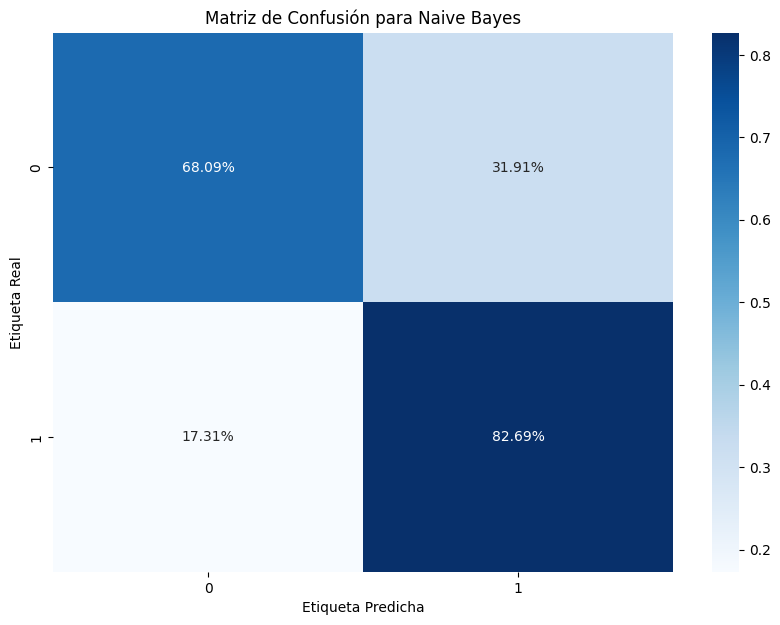

Reporte de Clasificación para Naive Bayes:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73        47
           1       0.74      0.83      0.78        52

    accuracy                           0.76        99
   macro avg       0.76      0.75      0.75        99
weighted avg       0.76      0.76      0.76        99

F1-Score para Naive Bayes: 0.755922865013774


El mejor modelo es: Random Forest con una exactitud = 0.81


In [12]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, LinearSVC, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una SparkSession
spark = SparkSession.builder.appName("heart_2").getOrCreate()

# Cargar el archivo CSV en un DataFrame de PySpark
file_path = "heart.csv"
spark_df = spark.read.csv(file_path, header=True, inferSchema=True)

# Mostrar las primeras filas del DataFrame
spark_df.show()

# Definir las características y la etiqueta
feature_columns = ["age", "sex", "cp", "trtbps", "chol", "fbs", "restecg", "thalachh", "exng", "oldpeak", "slp", "caa", "thall"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Transformar los datos
data = assembler.transform(spark_df)
data = data.select(["features", "output"])

# Dividir los datos en entrenamiento y prueba
train_data, test_data = data.randomSplit([0.7, 0.3], seed=1234)

# Definir los modelos
models = [
    ("Logistic Regression", LogisticRegression(featuresCol='features', labelCol='output')),
    ("Decision Tree", DecisionTreeClassifier(featuresCol='features', labelCol='output')),
    ("Random Forest", RandomForestClassifier(featuresCol='features', labelCol='output')),
    ("GBT", GBTClassifier(featuresCol='features', labelCol='output')),
    ("SVM", LinearSVC(featuresCol='features', labelCol='output')),
    ("Naive Bayes", NaiveBayes(featuresCol='features', labelCol='output'))
]

# Evaluador
evaluator = MulticlassClassificationEvaluator(labelCol="output", predictionCol="prediction", metricName="accuracy")

best_acc = 0.0
best_model_name = ""

# Entrenar y evaluar los modelos
for name, model in models:
    model_fit = model.fit(train_data)
    predictions = model_fit.transform(test_data)

    # Convertir las predicciones a un DataFrame de pandas
    predictions_pd = predictions.select("prediction", "output").toPandas()

    # Matriz de confusión y Reporte de clasificación
    cm = confusion_matrix(predictions_pd['output'], predictions_pd['prediction'])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=["0", "1"], yticklabels=["0", "1"])
    plt.title(f'Matriz de Confusión para {name}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.show()
    print(f"Reporte de Clasificación para {name}:\n{classification_report(predictions_pd['output'], predictions_pd['prediction'])}")

    # F1-Score
    f1_score = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
    print(f"F1-Score para {name}: {f1_score}\n")

    if evaluator.evaluate(predictions) > best_acc:
        best_acc = evaluator.evaluate(predictions)
        best_model_name = name

print(f"\nEl mejor modelo es: {best_model_name} con una exactitud = {best_acc:.2f}")
